# Notebook 2b — Adding TimesFM-3 (Google) and Prophet (Meta) to the forecasting comparison
### MediLLM: LLM-Augmented Dengue Outbreak Forecasting and Risk Reasoning in Bangladesh

**What this notebook does.** It adds two new forecasters to the comparison you already have in Notebook 2, evaluated on *exactly the same problem*:
same weekly national series, same 16 held-out target weeks, same horizons (1, 2, 4, 8 weeks ahead), same metrics.

| Model | Type | Uses covariates? | Trained on your data? |
|---|---|---|---|
| **TimesFM-3** (univariate) | pretrained foundation model, zero-shot | no | no (zero-shot) |
| **TimesFM-3** (+ covariates) | pretrained foundation model, zero-shot | yes: weather (past-only), season + Eid (known-future) | no (zero-shot) |
| **Prophet** (additive and multiplicative) | trend + seasonality model | Eid window | yes (refit at every forecast origin) |
| Persistence / Naive | baselines | no | no |

**Protocol (rolling-origin, no leakage).** For every target week *T* in the holdout and every horizon *h*, the forecast is made from origin *T − h weeks* using **only data up to that origin**. Prophet is refit at each origin; TimesFM-3 just receives the history as context.

**Why persistence is included:** in Notebook 2 the simple "same as h weeks ago" baseline beat every ML/DL model. Any new model has to beat *that* to be worth reporting, so every table below shows skill relative to persistence.

**Your data:** the notebook reads `dengue_weather_weekly_merged.csv` (Notebook 1 output) from Drive. If that file is not found it automatically uses a built-in copy of your real weekly case counts (156 weeks), so it always runs on your real series; the printed `DATA SOURCE` line tells you which one was used.

**Licence note (for the paper):** TimesFM-3 weights are released under Google's *non-commercial* licence (fine for research; not for production use). Cite the model and licence accurately.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Install
TimesFM-3 was released on 31 Aug 2026. The PyPI `timesfm` package was last updated *before* that, so install from GitHub to be sure you get the `timesfm3` module. If the import cell below still fails after this, use **Runtime → Restart session** once and run from the top (do not skip the install cell).

In [2]:
!pip -q install prophet
!pip -q install "timesfm[torch] @ git+https://github.com/google-research/timesfm.git"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os, glob, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

# ---- same BASE_DIR as Notebooks 1-4 ----
BASE_DIR = '/content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset'
OUTPUT_DIR = os.path.join(BASE_DIR, 'processed')
FIG_DIR    = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(base_dir, filename):
    m = glob.glob(os.path.join(base_dir, '**', filename), recursive=True)
    return m[0] if m else None

merged_path = find_file(OUTPUT_DIR, 'dengue_weather_weekly_merged.csv')
print('Merged file from Notebook 1:', merged_path)

Merged file from Notebook 1: /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/dengue_weather_weekly_merged.csv


## 2. Data, known-future features, and the evaluation set
Rebuilt exactly as in Notebook 2 (same Eid dates, same 16-week holdout), but the **full** series (all 156 weeks) is kept as context, because TimesFM and Prophet do not need lag columns.

In [4]:
# Your real weekly national dengue cases, 2023-W01 .. 2025-W52 (156 weeks; copied from Notebook 1, Table 2).
# Used ONLY if the merged file from Notebook 1 is not found on Drive.
REAL_WEEKLY_CASES = [105, 56, 51, 26, 30, 25, 22, 14, 14, 21, 16, 14, 19, 21, 20, 8, 37, 82, 120, 140, 247, 515, 687, 1299, 1755, 877, 2386, 6779, 11298, 15794, 17625, 18622, 15433, 14395, 15591, 17739, 19315, 20244, 18785, 17506, 16508, 15827, 12953, 12005, 12356, 9957, 7284, 5802, 3832, 2235, 1305, 811, 362, 267, 189, 160, 112, 117, 61, 59, 77, 65, 65, 83, 64, 72, 67, 146, 157, 135, 153, 180, 151, 124, 162, 176, 136, 264, 285, 519, 402, 683, 1255, 1016, 1450, 1742, 1882, 2366, 3382, 4519, 5458, 6801, 6443, 6772, 7081, 7502, 7891, 7539, 7116, 5756, 4163, 2872, 1525, 1185, 0, 221, 352, 258, 190, 149, 88, 127, 99, 70, 44, 117, 96, 56, 35, 172, 153, 238, 189, 318, 394, 491, 488, 585, 809, 1690, 2053, 2470, 2506, 754, 3906, 2207, 2408, 2177, 2290, 2706, 2923, 3375, 685, 3196, 4115, 3656, 4741, 5293, 5398, 6216, 6835, 6510, 5628, 4280, 3552, 2777]

if merged_path:
    df = pd.read_csv(merged_path, parse_dates=['week_start']).sort_values('week_start').reset_index(drop=True)
    DATA_SOURCE = 'Drive: dengue_weather_weekly_merged.csv (cases + weather)'
else:
    df = pd.DataFrame({'week_start': pd.date_range('2023-01-02', periods=len(REAL_WEEKLY_CASES), freq='7D'),
                       'dengue_cases': REAL_WEEKLY_CASES})
    DATA_SOURCE = 'built-in copy of your real weekly cases (no weather columns)'
print('DATA SOURCE:', DATA_SOURCE)

y_all = df['dengue_cases'].astype(float).values
print('Series length:', len(df), '|', df['week_start'].min().date(), '->', df['week_start'].max().date())

# Same Eid dates as Notebook 2 (known well in advance => legitimate "known-future" covariate)
eid_dates = pd.to_datetime(['2023-04-22', '2023-06-29', '2024-04-11', '2024-06-17', '2025-03-31', '2025-06-07'])

def known_future(dates):
    """Covariates that are known for future weeks: (3, n) = [week_sin, week_cos, is_eid_window]."""
    dates = pd.DatetimeIndex(dates)
    wk = dates.isocalendar().week.values.astype(float)
    d2e = np.abs((dates.values[:, None] - eid_dates.values[None, :]) / np.timedelta64(1, 'D')).min(axis=1)
    return np.vstack([np.sin(2 * np.pi * wk / 52), np.cos(2 * np.pi * wk / 52), (d2e <= 10).astype(float)])

PAST_ONLY_COLS = [c for c in ['avg_temp', 'avg_humidity', 'total_rain'] if c in df.columns]   # weather: known only up to the origin
print('Past-only (weather) covariates available:', PAST_ONLY_COLS)

HOLDOUT_WEEKS = 16
HORIZONS = [1, 2, 4, 8]
H_MAX = max(HORIZONS)

n = len(df)
tgt_pos = np.arange(n - HOLDOUT_WEEKS, n)                 # the 16 target weeks (same as Notebook 2's test_df)
origins_needed = sorted({t - h for t in tgt_pos for h in HORIZONS})
print('Target weeks:', df['week_start'].iloc[tgt_pos[0]].date(), '->', df['week_start'].iloc[tgt_pos[-1]].date())
print('Distinct forecast origins needed:', len(origins_needed))

DATA SOURCE: Drive: dengue_weather_weekly_merged.csv (cases + weather)
Series length: 156 | 2023-01-02 -> 2025-12-22
Past-only (weather) covariates available: ['avg_temp', 'avg_humidity', 'total_rain']
Target weeks: 2025-09-08 -> 2025-12-22
Distinct forecast origins needed: 23


## 3. Metrics and baselines

In [5]:
def mae(y, p):  return float(np.mean(np.abs(y - p)))
def rmse(y, p): return float(np.sqrt(np.mean((y - p) ** 2)))
def mape(y, p, eps=1.0): return float(np.mean(np.abs(y - p) / np.maximum(y, eps)) * 100)

rows = []   # long table: one row per (model, horizon, target week)

def add_rows(model, preds, lo=None, hi=None):
    """preds/lo/hi: dict origin_pos -> array of length H_MAX (step 1..H_MAX ahead)."""
    for h in HORIZONS:
        for t in tgt_pos:
            o = t - h
            rows.append({
                'model': model, 'horizon': h,
                'target_week': df['week_start'].iloc[t], 'origin_week': df['week_start'].iloc[o],
                'y_true': y_all[t], 'y_pred': float(max(preds[o][h - 1], 0.0)),
                'lo80': np.nan if lo is None else float(max(lo[o][h - 1], 0.0)),
                'hi80': np.nan if hi is None else float(max(hi[o][h - 1], 0.0)),
            })

# Persistence: forecast = last observed value at the origin (identical to Notebook 2's 'Persistence (lag-h)')
persist = {o: np.full(H_MAX, y_all[o]) for o in origins_needed}
add_rows('Persistence', persist)
print('Persistence done.')

# Sanity check: these must equal Notebook 2's "Persistence (lag-h)" MAE (905.3, 1262.4, 1735.6, 2255.9)
_chk = {h: round(float(np.mean([abs(y_all[t] - y_all[t - h]) for t in tgt_pos])), 1) for h in HORIZONS}
print('Persistence MAE (this notebook):', _chk)
print('Notebook 2 reported            :', {1: 905.3, 2: 1262.4, 4: 1735.6, 8: 2255.9})

Persistence done.
Persistence MAE (this notebook): {1: 905.3, 2: 1262.4, 4: 1735.6, 8: 2255.9}
Notebook 2 reported            : {1: 905.3, 2: 1262.4, 4: 1735.6, 8: 2255.9}


## 4. TimesFM-3 (Google), zero-shot
Two variants so you can show what covariates add:
- **univariate:** only the case history.
- **+ covariates:** case history + weather as *past-only* covariates + `week_sin`, `week_cos`, `is_eid_window` as *past-and-future* covariates.

Output has 9 quantiles (0.1 … 0.9); the 80 % interval is q10–q90 and the point forecast is the median. No training or tuning happens here.

In [6]:
import torch
try:
    from timesfm3 import TimesFM3Evaluator, ModelConfig
except ImportError as e:
    raise ImportError('timesfm3 not found. Re-run the install cell, then Runtime > Restart session, then run from the top. '
                      'Original error: ' + str(e))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
config = ModelConfig(checkpoint_path='google/timesfm-3.0-pytorch', per_core_batch_size=8, device=device)
forecaster = TimesFM3Evaluator(config)
print('TimesFM-3 loaded.')

# quick self-check on one origin: shapes must be (H,) forecast and (H, 9) quantiles
_o = origins_needed[0]
_out = list(forecaster.predict_batch([y_all[:_o + 1].astype(np.float32)], horizon=H_MAX, return_quantiles=True, use_symmetric_averaging=False))[0]
print('self-check -> forecast', np.asarray(_out.forecast).shape, '| quantiles', np.asarray(_out.quantiles).shape)

Device: cpu


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.32GB            

model.safetensors: downloading bytes:           |  0.00B            

TimesFM-3 loaded.
self-check -> forecast (8,) | quantiles (8, 9)


In [7]:
def tfm_forecast(origin_pos, use_covariates):
    ctx = y_all[:origin_pos + 1].astype(np.float32)
    kw = dict(horizon=H_MAX, return_quantiles=True, use_symmetric_averaging=False)
    if not use_covariates:
        out = list(forecaster.predict_batch([ctx], **kw))[0]
    else:
        L = len(ctx)
        dates_ctx_fut = pd.date_range(df['week_start'].iloc[0], periods=L + H_MAX, freq='7D')
        past_fut = known_future(dates_ctx_fut).astype(np.float32)                                    # (3, L + H)
        kw2 = dict(past_future_covariates=[past_fut])
        if PAST_ONLY_COLS:
            kw2['past_only_covariates'] = [df[PAST_ONLY_COLS].iloc[:origin_pos + 1].values.T.astype(np.float32)]   # (n_weather, L)
        out = list(forecaster.predict_batch([ctx[None, :]], **kw2, **kw))[0]
    f = np.asarray(out.forecast).reshape(-1)[:H_MAX]
    q = np.asarray(out.quantiles).reshape(-1, 9)[:H_MAX]          # (H, 9): index 0 = q10, 4 = median, 8 = q90
    return f, q[:, 0], q[:, 8]

for use_cov, name in [(False, 'TimesFM-3 (univariate)'), (True, 'TimesFM-3 (+covariates)')]:
    P, LO, HI = {}, {}, {}
    for o in origins_needed:
        P[o], LO[o], HI[o] = tfm_forecast(o, use_cov)
    add_rows(name, P, LO, HI)
    print(name, 'done.')

TimesFM-3 (univariate) done.
TimesFM-3 (+covariates) done.


## 5. Prophet (Meta), refit at every origin
Two variants (additive and multiplicative seasonality) are run with identical fixed settings and both are reported, so nothing is tuned on the test weeks. Only `is_eid_window` is used as a regressor, because it is the only exogenous signal Prophet can use without needing *future* weather (which is unknown at forecast time). Yearly seasonality is kept low-order (`PROPHET_FOURIER`) because there are only ~3 years of data — a high order would overfit. Change the two settings below if you want to test other choices.

In [8]:
from prophet import Prophet
for _n in ('cmdstanpy', 'prophet', 'prophet.plot'):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False; _lg.handlers = []

PROPHET_FOURIER = 3            # yearly seasonality order (only ~3 years of data => keep small)

def prophet_forecast(origin_pos, mode):
    hist = pd.DataFrame({'ds': df['week_start'].iloc[:origin_pos + 1].values, 'y': y_all[:origin_pos + 1]})
    hist['eid'] = known_future(hist['ds'])[2]
    m = Prophet(growth='linear', yearly_seasonality=PROPHET_FOURIER, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode=mode, interval_width=0.8)
    m.add_regressor('eid')
    m.fit(hist)
    fut = pd.DataFrame({'ds': pd.date_range(hist['ds'].iloc[-1] + pd.Timedelta(weeks=1), periods=H_MAX, freq='7D')})
    fut['eid'] = known_future(fut['ds'])[2]
    fc = m.predict(fut)
    return fc['yhat'].values, fc['yhat_lower'].values, fc['yhat_upper'].values

# Both variants are reported (fixed settings, NOT tuned on the test weeks).
for mode in ['additive', 'multiplicative']:
    P, LO, HI = {}, {}, {}
    for i, o in enumerate(origins_needed, 1):
        P[o], LO[o], HI[o] = prophet_forecast(o, mode)
    add_rows(f'Prophet ({mode})', P, LO, HI)
    print(f'Prophet ({mode}) done.')

09:09:18 - cmdstanpy - INFO - Chain [1] start processing
09:09:18 - cmdstanpy - INFO - Chain [1] done processing
09:09:19 - cmdstanpy - INFO - Chain [1] start processing
09:09:19 - cmdstanpy - INFO - Chain [1] done processing
09:09:20 - cmdstanpy - INFO - Chain [1] start processing
09:09:20 - cmdstanpy - INFO - Chain [1] done processing
09:09:20 - cmdstanpy - INFO - Chain [1] start processing
09:09:20 - cmdstanpy - INFO - Chain [1] done processing
09:09:20 - cmdstanpy - INFO - Chain [1] start processing
09:09:20 - cmdstanpy - INFO - Chain [1] done processing
09:09:20 - cmdstanpy - INFO - Chain [1] start processing
09:09:20 - cmdstanpy - INFO - Chain [1] done processing
09:09:20 - cmdstanpy - INFO - Chain [1] start processing
09:09:20 - cmdstanpy - INFO - Chain [1] done processing
09:09:20 - cmdstanpy - INFO - Chain [1] start processing
09:09:20 - cmdstanpy - INFO - Chain [1] done processing
09:09:21 - cmdstanpy - INFO - Chain [1] start processing
09:09:21 - cmdstanpy - INFO - Chain [1]

Prophet (additive) done.


09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1] done processing
09:09:23 - cmdstanpy - INFO - Chain [1] start processing
09:09:23 - cmdstanpy - INFO - Chain [1]

Prophet (multiplicative) done.


## 6. Results
**Table 19** — accuracy and interval quality per model and horizon. `skill_vs_persistence` = 1 − MAE/MAE(persistence): positive means better than persistence, negative means worse.

In [9]:
res = pd.DataFrame(rows)
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()

def summarize(g):
    y, p = g['y_true'].values, g['y_pred'].values
    out = {'MAE': mae(y, p), 'RMSE': rmse(y, p), 'MAPE_%': mape(y, p), 'n': len(g)}
    if g['lo80'].notna().all():
        out['coverage_80'] = float(np.mean((y >= g['lo80'].values) & (y <= g['hi80'].values)))
        out['mean_width'] = float(np.mean(g['hi80'].values - g['lo80'].values))
    return out

table19 = pd.DataFrame([{'model': m, 'horizon': h, **summarize(g)} for (m, h), g in res.groupby(['model', 'horizon'])])
pers_mae = table19[table19.model == 'Persistence'].set_index('horizon')['MAE']
table19['skill_vs_persistence'] = 1 - table19['MAE'] / table19['horizon'].map(pers_mae)
table19 = table19.round(3)
print('Table 19. Rolling-origin results on the 16 held-out weeks')
display(table19)

mae_pivot = table19.pivot(index='model', columns='horizon', values='MAE')
print('\nMAE by model and horizon (lower is better):')
display(mae_pivot.round(1))
print('Best model per horizon:', mae_pivot.idxmin().to_dict())
table19.to_csv(os.path.join(FIG_DIR, 'table19_timesfm_prophet_results.csv'), index=False)

Table 19. Rolling-origin results on the 16 held-out weeks


,model,horizon,MAE,RMSE,MAPE_%,n,coverage_80,mean_width,skill_vs_persistence
0,Persistence,1,905.312,1151.748,42.813,16,NaN,NaN,0.000
1,Persistence,2,1262.438,1528.287,47.034,16,NaN,NaN,0.000
2,Persistence,4,1735.625,2083.340,53.440,16,NaN,NaN,0.000
3,Persistence,8,2255.875,2617.516,73.349,16,NaN,NaN,0.000
4,Prophet (additive),1,3234.347,3595.338,133.485,16,0.688,6846.789,-2.573
5,Prophet (additive),2,3439.350,3819.019,140.241,16,0.500,6742.868,-1.724
6,Prophet (additive),4,3794.129,4220.152,155.316,16,0.312,6531.692,-1.186
7,Prophet (additive),8,4140.814,4596.889,171.397,16,0.375,6535.950,-0.836
8,Prophet (multiplicative),1,2376.574,2759.461,70.355,16,0.375,3697.036,-1.625
9,Prophet (multiplicative),2,2497.791,2867.725,73.316,16,0.375,3643.019,-0.979



MAE by model and horizon (lower is better):


horizon,1,2,4,8
model,,,,
Persistence,905.3,1262.4,1735.6,2255.9
Prophet (additive),3234.3,3439.4,3794.1,4140.8
Prophet (multiplicative),2376.6,2497.8,2727.9,3963.9
TimesFM-3 (+covariates),761.2,1100.8,1890.4,3559.2
TimesFM-3 (univariate),721.2,1215.3,2331.3,6138.4


Best model per horizon: {1: 'TimesFM-3 (univariate)', 2: 'TimesFM-3 (+covariates)', 4: 'Persistence', 8: 'Persistence'}


**Is the difference from persistence real?** With only 16 target weeks, small MAE gaps can be noise. This is a paired bootstrap over the 16 weeks on the *difference in absolute error* (model − persistence). If the 95 % interval is entirely below 0, the model is significantly better than persistence.

In [10]:
rng = np.random.default_rng(42)
pers = res[res.model == 'Persistence'].set_index(['horizon', 'target_week'])['abs_err']

boot_rows = []
for (m, h), g in res[res.model != 'Persistence'].groupby(['model', 'horizon']):
    d = (g.set_index(['horizon', 'target_week'])['abs_err'] - pers.loc[g.set_index(['horizon', 'target_week']).index]).values
    means = [rng.choice(d, size=len(d), replace=True).mean() for _ in range(5000)]
    lo, hi = np.percentile(means, [2.5, 97.5])
    verdict = 'better' if hi < 0 else ('worse' if lo > 0 else 'no clear difference')
    boot_rows.append({'model': m, 'horizon': h, 'mean_err_diff_vs_persistence': round(d.mean(), 1),
                      'ci95_low': round(lo, 1), 'ci95_high': round(hi, 1), 'vs_persistence': verdict})
table20 = pd.DataFrame(boot_rows)
print('Table 20. Paired bootstrap vs persistence (negative diff = model has smaller error)')
display(table20)
table20.to_csv(os.path.join(FIG_DIR, 'table20_bootstrap_vs_persistence.csv'), index=False)

Table 20. Paired bootstrap vs persistence (negative diff = model has smaller error)


,model,horizon,mean_err_diff_vs_persistence,ci95_low,ci95_high,vs_persistence
0,Prophet (additive),1,2329.0,1690.0,2996.6,worse
1,Prophet (additive),2,2176.9,1281.2,3033.0,worse
2,Prophet (additive),4,2058.5,822.1,3288.7,worse
3,Prophet (additive),8,1884.9,575.0,3151.2,worse
4,Prophet (multiplicative),1,1471.3,636.4,2276.6,worse
5,Prophet (multiplicative),2,1235.4,478.1,2033.1,worse
6,Prophet (multiplicative),4,992.3,180.6,1817.5,worse
7,Prophet (multiplicative),8,1708.0,491.9,3148.4,worse
8,TimesFM-3 (+covariates),1,-144.1,-347.1,29.0,no clear difference
9,TimesFM-3 (+covariates),2,-161.7,-593.2,227.2,no clear difference


## 7. Figures

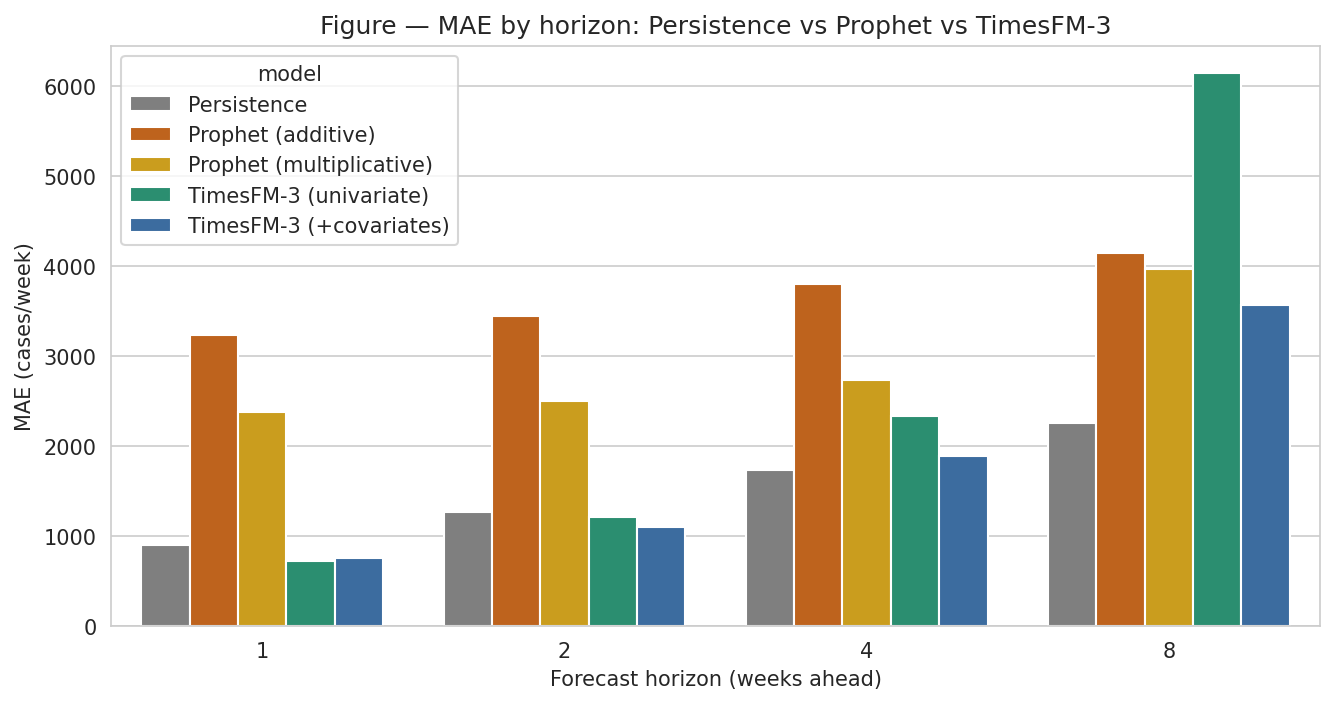

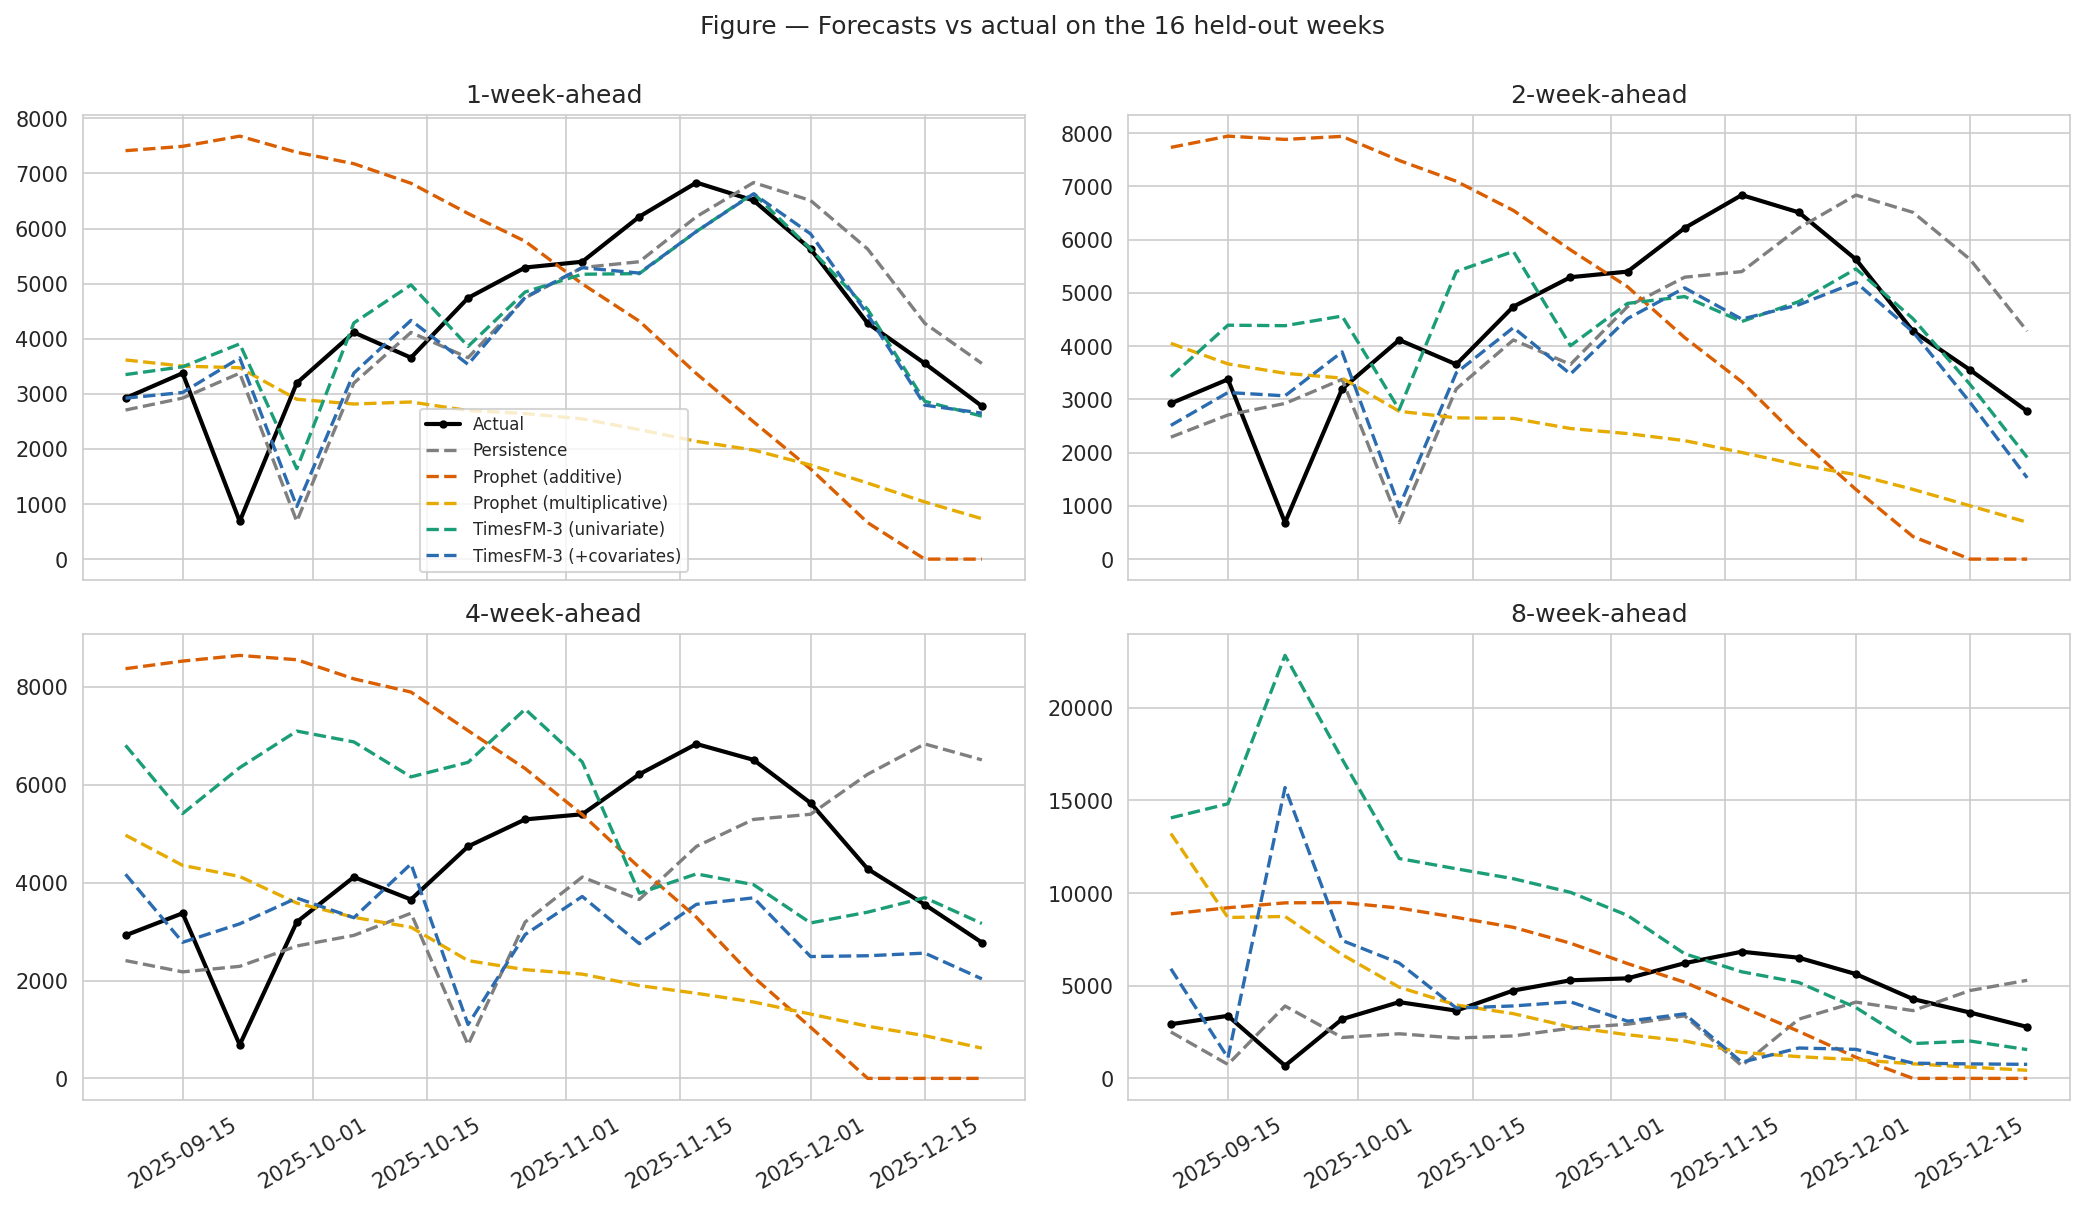

In [11]:
order = ['Persistence', 'Prophet (additive)', 'Prophet (multiplicative)', 'TimesFM-3 (univariate)', 'TimesFM-3 (+covariates)']
colors = dict(zip(order, ['#7f7f7f', '#d95f02', '#e6ab02', '#1b9e77', '#2b6cb0']))

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = table19[table19.model.isin(order)]
sns.barplot(data=plot_df, x='horizon', y='MAE', hue='model', hue_order=order, palette=colors, ax=ax)
ax.set_xlabel('Forecast horizon (weeks ahead)'); ax.set_ylabel('MAE (cases/week)')
ax.set_title('Figure — MAE by horizon: Persistence vs Prophet vs TimesFM-3')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig_timesfm_prophet_mae.png'), dpi=200); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, h in zip(axes.ravel(), HORIZONS):
    g0 = res[(res.model == 'Persistence') & (res.horizon == h)].sort_values('target_week')
    ax.plot(g0['target_week'], g0['y_true'], 'k-o', ms=3, lw=2, label='Actual')
    for m in order:
        g = res[(res.model == m) & (res.horizon == h)].sort_values('target_week')
        ax.plot(g['target_week'], g['y_pred'], '--', color=colors[m], lw=1.6, label=m)
    ax.set_title(f'{h}-week-ahead'); ax.tick_params(axis='x', rotation=30)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Figure — Forecasts vs actual on the 16 held-out weeks', y=1.0)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, 'fig_timesfm_prophet_forecasts.png'), dpi=200); plt.show()

## 8. Side-by-side with Notebook 2's tree models, then save
Notebook 2 evaluated XGBoost/LightGBM on the same 16 target weeks, so their MAE/RMSE/MAPE can sit in the same table. (Notebook 2's LSTM/TFT/PatchTST rows are **not** merged: their MAE is identical across horizons, which means they were not evaluated per-horizon — fix that in Notebook 2 first.)

In [12]:
nb2_path = find_file(OUTPUT_DIR, 'model_comparison_results.csv')
final = table19[['model', 'horizon', 'MAE', 'RMSE', 'MAPE_%']].copy()
if nb2_path:
    nb2 = pd.read_csv(nb2_path)
    nb2 = nb2[nb2['model'].isin(['XGBoost', 'LightGBM'])].rename(columns={'mae': 'MAE', 'rmse': 'RMSE', 'mape': 'MAPE_%'})
    final = pd.concat([final, nb2[['model', 'horizon', 'MAE', 'RMSE', 'MAPE_%']]], ignore_index=True)
    print('Merged XGBoost/LightGBM from Notebook 2.')
else:
    print('model_comparison_results.csv not found - showing only the models from this notebook.')

pivot = final.pivot_table(index='model', columns='horizon', values='MAE').round(1)
pivot.columns = [f'{h}-week MAE' for h in pivot.columns]
print('Table 21. MAE by model and horizon (same 16 target weeks)')
display(pivot.sort_values(pivot.columns[0]))
pivot.to_csv(os.path.join(FIG_DIR, 'table21_all_models_mae.csv'))

res.drop(columns=['abs_err']).to_csv(os.path.join(OUTPUT_DIR, 'timesfm_prophet_forecasts_long.csv'), index=False)
print('Saved forecasts to', os.path.join(OUTPUT_DIR, 'timesfm_prophet_forecasts_long.csv'))

Merged XGBoost/LightGBM from Notebook 2.
Table 21. MAE by model and horizon (same 16 target weeks)


,1-week MAE,2-week MAE,4-week MAE,8-week MAE
model,,,,
TimesFM-3 (univariate),721.2,1215.3,2331.3,6138.4
TimesFM-3 (+covariates),761.2,1100.8,1890.4,3559.2
Persistence,905.3,1262.4,1735.6,2255.9
XGBoost,1587.6,2118.5,2114.8,1933.2
LightGBM,2349.2,2759.9,2326.1,2996.0
Prophet (multiplicative),2376.6,2497.8,2727.9,3963.9
Prophet (additive),3234.3,3439.4,3794.1,4140.8


Saved forecasts to /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/timesfm_prophet_forecasts_long.csv


## How to read the result (and what to tell your supervisor)
1. **Look at Table 20 first.** A model only counts as an improvement if it is *significantly* better than persistence. Otherwise the honest statement is "no clear difference".
2. **TimesFM-3 (univariate) vs (+covariates)** tells you whether weather/season/Eid actually help a foundation model on this small series.
3. **Prophet** is a useful classical reference; if it is worse than persistence, that is a legitimate negative result, report it as such.
4. **Coverage (Table 19):** an 80 % interval should cover ≈ 80 % of actuals. Notebook 2's LightGBM intervals covered only 12–31 %, so compare `coverage_80` here.
5. **Explainability caveat:** your LLM layer currently explains LightGBM through SHAP. TimesFM-3 and Prophet do not give SHAP values, so if one of them becomes the main forecaster the explanation layer must change (e.g. Prophet's trend/seasonality/Eid components, or keep LightGBM as the explanation model and use TimesFM-3 as the accuracy benchmark).
